<a href="https://www.kaggle.com/code/lalit7881/chocolate-sales-in-2022-23-eda?scriptVersionId=329365713" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv")


In [3]:
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


In [4]:
df.tail()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
199995,ORD-053460,70% Dark Bar,Australia,Retail,Beatriz Souza,2022-05-27,10.6,3.39,186.19,125,418.56
199996,ORD-010743,Truffle Gift Box,India,Wholesale,Arjun Mehta,2022-09-06,17.3,3.07,42.28,148,366.47
199997,ORD-049690,Salted Caramel Bar,Japan,Online,Arjun Mehta,2022-06-16,18.3,2.74,100.19,149,329.79
199998,ORD-189637,85% Dark Bar,Japan,Wholesale,Rohan Patel,2022-10-14,9.3,14.30,29.96,24,304.51
199999,ORD-061616,Mint Dark Bar,Australia,Retail,Hannah Müller,2022-01-25,7.2,3.01,270.86,131,366.91


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


In [6]:
df.describe()

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped
count,199511.000000,199543.000000,199539.000000,200000.000000
mean,13.107457,5.911507,95.450141,139.584105
std,6.374477,4.954976,66.243760,118.665393
min,0.000000,2.040000,4.300000,-1642.000000
25%,8.300000,2.950000,52.270000,67.000000
50%,12.600000,3.280000,78.850000,113.000000
75%,17.500000,4.570000,118.710000,180.000000
max,38.300000,21.650000,798.222443,3811.000000


In [7]:
df.isnull().sum()

Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Order_ID            object
Product             object
Country             object
Channel             object
Salesperson         object
Order_Date          object
Discount_Pct       float64
Price_per_Box      float64
Marketing_Spend    float64
Boxes_Shipped        int64
Amount              object
dtype: object

In [10]:
df.shape

(200000, 11)

In [11]:
df.columns

Index(['Order_ID', 'Product', 'Country', 'Channel', 'Salesperson',
       'Order_Date', 'Discount_Pct', 'Price_per_Box', 'Marketing_Spend',
       'Boxes_Shipped', 'Amount'],
      dtype='object')

In [12]:
df.nunique()

Order_ID           200000
Product                12
Country                 5
Channel                 3
Salesperson            25
Order_Date           2000
Discount_Pct         2517
Price_per_Box        1381
Marketing_Spend     27319
Boxes_Shipped        1521
Amount              85605
dtype: int64

## EDA

<class 'pandas.core.frame.DataFrame'>
Index: 195666 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Order_ID         195666 non-null  object        
 1   Product          195666 non-null  object        
 2   Country          195666 non-null  object        
 3   Channel          195666 non-null  object        
 4   Salesperson      195666 non-null  object        
 5   Order_Date       195666 non-null  datetime64[ns]
 6   Discount_Pct     195666 non-null  float64       
 7   Price_per_Box    195666 non-null  float64       
 8   Marketing_Spend  195666 non-null  float64       
 9   Boxes_Shipped    195666 non-null  int64         
 10  Amount           195666 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 17.9+ MB
None
                          Order_Date   Discount_Pct  Price_per_Box  \
count                         19566

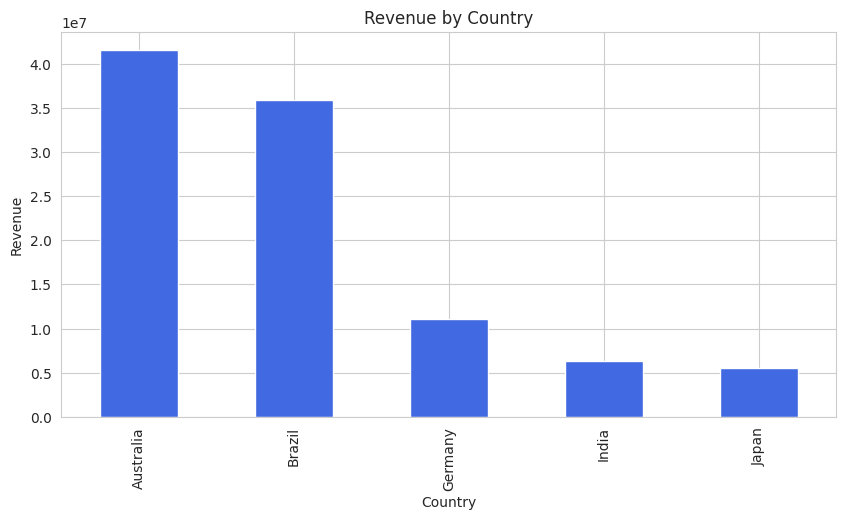

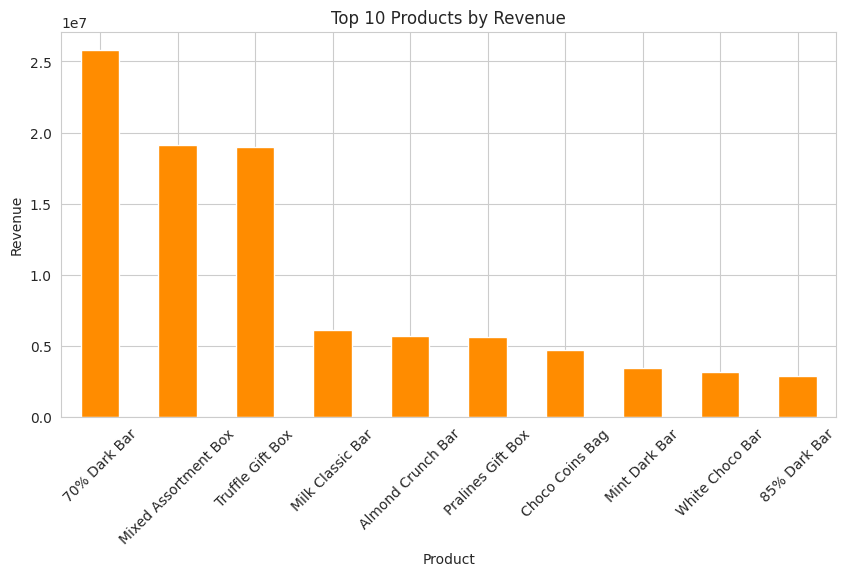

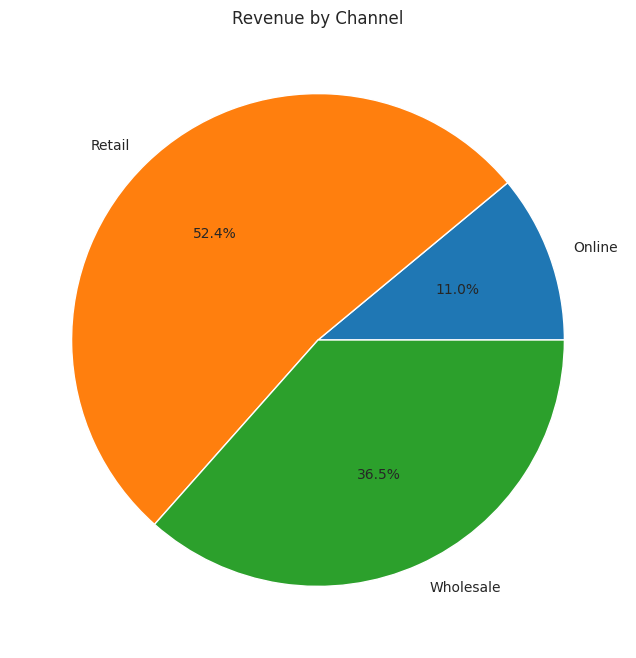

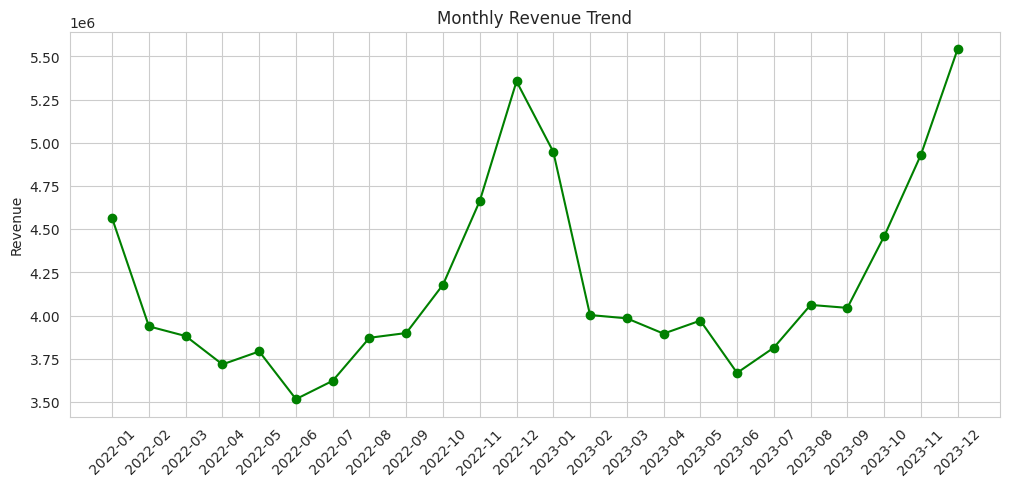

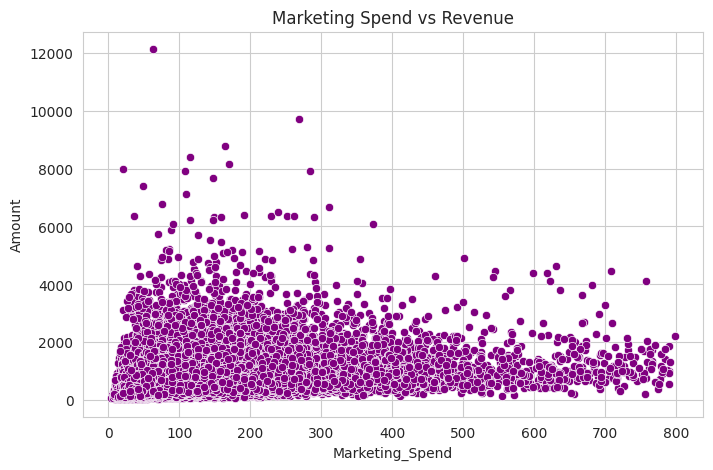

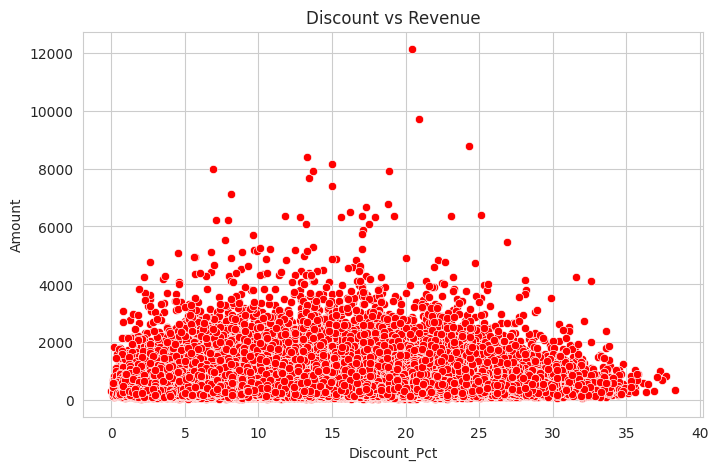

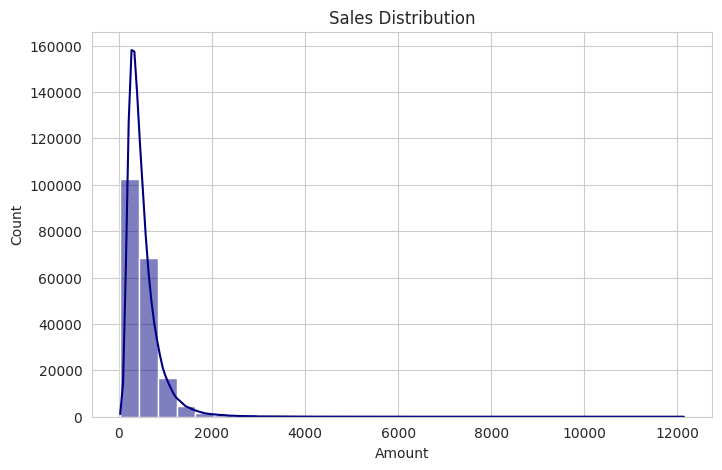

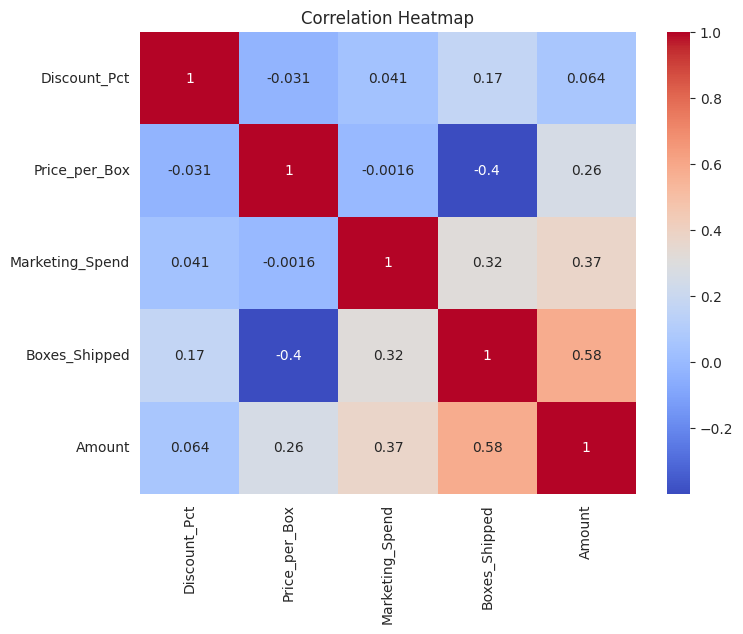

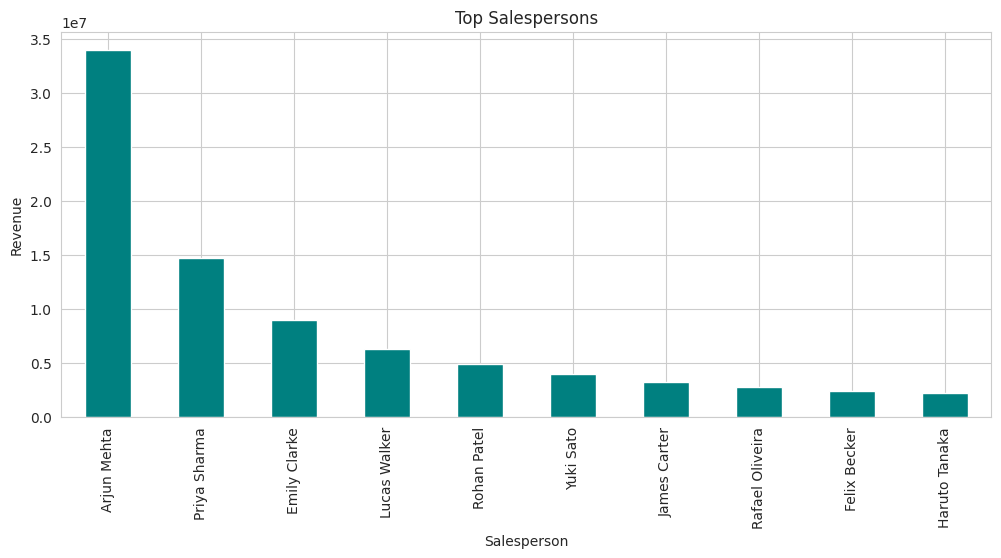

Visualization Completed Successfully


In [13]:
# Date
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Numeric columns
num_cols = [
    'Discount_Pct',
    'Price_per_Box',
    'Marketing_Spend',
    'Boxes_Shipped',
    'Amount'
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

# Remove missing values
df = df.dropna()

sns.set_style("whitegrid")

# ==========================
# 1. Dataset Info
# ==========================
print(df.info())
print(df.describe())

# ==========================
# 2. Revenue by Country
# ==========================
country_sales = (
    df.groupby('Country')['Amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

country_sales.plot(
    kind='bar',
    color='royalblue'
)

plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

# ==========================
# 3. Top 10 Products
# ==========================
top_products = (
    df.groupby('Product')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(
    kind='bar',
    color='darkorange'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# ==========================
# 4. Revenue by Channel
# ==========================
channel_sales = (
    df.groupby('Channel')['Amount']
      .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    channel_sales,
    labels=channel_sales.index,
    autopct='%1.1f%%'
)

plt.title('Revenue by Channel')
plt.show()

# ==========================
# 5. Monthly Sales Trend
# ==========================
monthly_sales = (
    df.groupby(
        df['Order_Date'].dt.to_period('M')
    )['Amount']
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o',
    color='green'
)

plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.ylabel('Revenue')
plt.show()

# ==========================
# 6. Marketing Spend vs Revenue
# ==========================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Amount',
    color='purple'
)

plt.title('Marketing Spend vs Revenue')
plt.show()

# ==========================
# 7. Discount vs Revenue
# ==========================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount_Pct',
    y='Amount',
    color='red'
)

plt.title('Discount vs Revenue')
plt.show()

# ==========================
# 8. Sales Distribution
# ==========================
plt.figure(figsize=(8,5))

sns.histplot(
    df['Amount'],
    bins=30,
    kde=True,
    color='navy'
)

plt.title('Sales Distribution')
plt.show()

# ==========================
# 9. Correlation Heatmap
# ==========================
corr_cols = [
    'Discount_Pct',
    'Price_per_Box',
    'Marketing_Spend',
    'Boxes_Shipped',
    'Amount'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# ==========================
# 10. Salesperson Performance
# ==========================
salesperson_sales = (
    df.groupby('Salesperson')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

salesperson_sales.plot(
    kind='bar',
    color='teal'
)

plt.title('Top Salespersons')
plt.ylabel('Revenue')
plt.show()

print("Visualization Completed Successfully")

## Feature engineering

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

Train Shape: (156532, 13)
Test Shape : (39134, 13)


Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     19568
           1       0.90      0.89      0.89     19566

    accuracy                           0.89     39134
   macro avg       0.89      0.89      0.89     39134
weighted avg       0.89      0.89      0.89     39134



Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     19568
           1       0.95      0.96      0.96     19566

    accuracy                           0.96     39134
   macro avg       0.96      0.96      0.96     39134
weighted avg       0.96      0.96      0.96     39134



Random Forest
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     19568
           1       0.93      0.91      0.92     19566

    accuracy                           0.92     39134
   macro avg       0.92

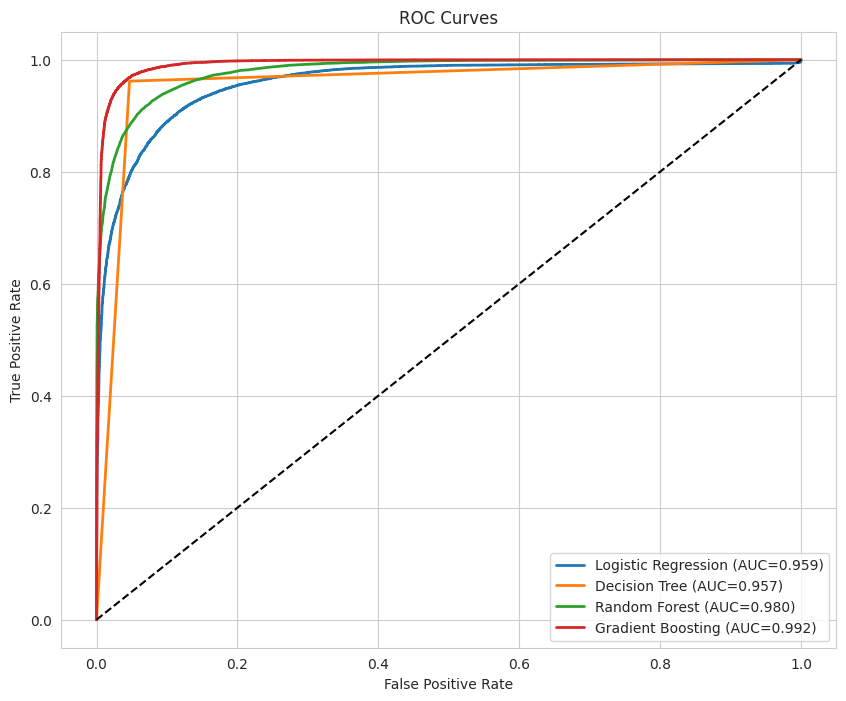


Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
3    Gradient Boosting  0.960622   0.957511  0.964019  0.960754  0.992363
2        Random Forest  0.923059   0.930783  0.914086  0.922359  0.979663
0  Logistic Regression  0.894491   0.898415  0.889553  0.893962  0.958637
1        Decision Tree  0.957454   0.953534  0.961770  0.957635  0.957454

Best Model: Gradient Boosting


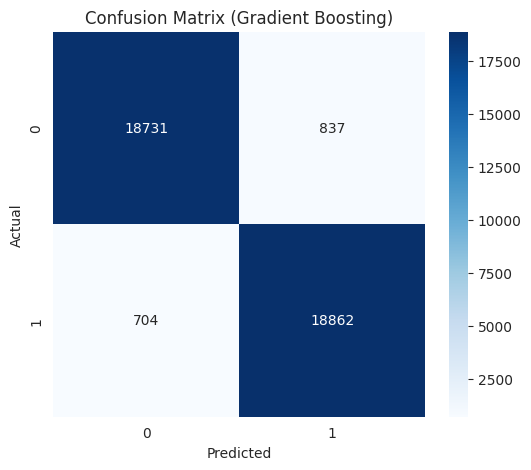

In [15]:
# ============================================
# Date Conversion
# ============================================

df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# ============================================
# Feature Engineering
# ============================================

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day
df['Weekday'] = df['Order_Date'].dt.dayofweek

# ============================================
# Create Target Variable
# ============================================

median_amount = df['Amount'].median()

df['Target'] = np.where(
    df['Amount'] > median_amount,
    1,
    0
)

# ============================================
# Remove Leakage Columns
# ============================================

X = df.drop(
    columns=[
        'Target',
        'Amount',
        'Order_Date'
    ]
)

y = df['Target']

# ============================================
# Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ============================================
# Categorical & Numerical Columns
# ============================================

categorical_cols = X.select_dtypes(
    include=['object']
).columns

numerical_cols = X.select_dtypes(
    exclude=['object']
).columns

# ============================================
# Preprocessing
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_cols
        ),
        (
            'num',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='median'))
            ]),
            numerical_cols
        )
    ]
)

# ============================================
# Models
# ============================================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

# ============================================
# Training & Evaluation
# ============================================

results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_prob = pipe.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC={roc_auc:.3f})'
    )

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

# ============================================
# ROC Curve
# ============================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# ============================================
# Results Table
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print("\nModel Comparison")
print(results_df)

# ============================================
# Best Model
# ============================================

best_model_name = results_df.iloc[0]['Model']

print("\nBest Model:", best_model_name)

# ============================================
# Confusion Matrix of Best Model
# ============================================

best_model = models[best_model_name]

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

best_pipe.fit(X_train, y_train)

best_pred = best_pipe.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix ({best_model_name})'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!